<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Correlation**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis (EDA). You will examine the distribution of the data, identify outliers, and determine the correlation between different columns in the dataset.


## Objectives


In this lab, you will perform the following:


- Identify the distribution of compensation data in the dataset.

- Remove outliers to refine the dataset.

- Identify correlations between various features in the dataset.


## Hands on Lab


##### Step 1: Install and Import Required Libraries


In [12]:
# Install the necessary libraries
!pip install pandas
!pip install matplotlib
!pip install seaborn

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [13]:
%matplotlib inline

### Step 2: Load the Dataset


In [14]:
# Load the dataset from the given URL
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# Display the first few rows to understand the structure of the dataset
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 3: Analyze and Visualize Compensation Distribution</h3>


**Task**: Plot the distribution and histogram for `ConvertedCompYearly` to examine the spread of yearly compensation among respondents.


In [15]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.

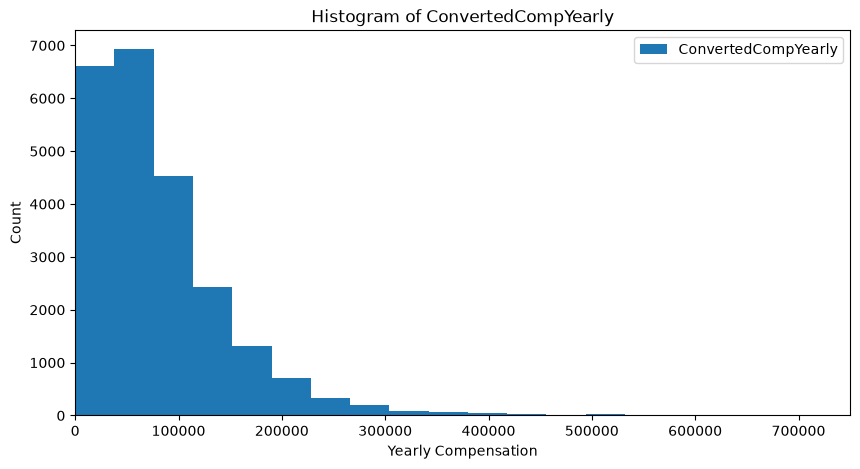

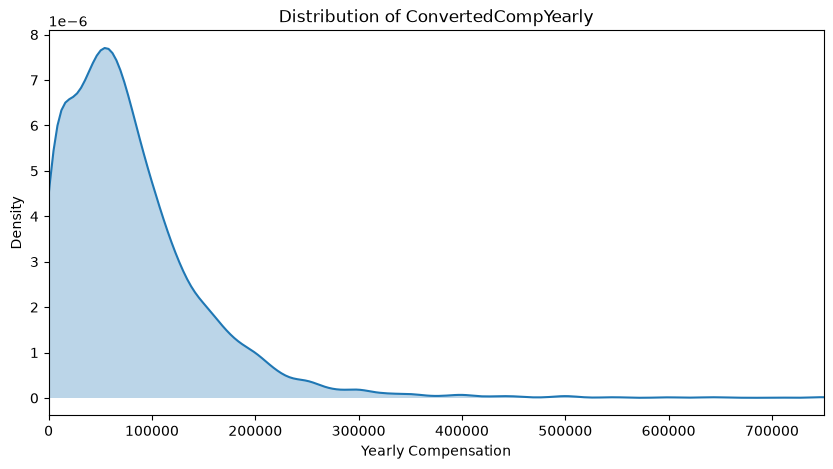

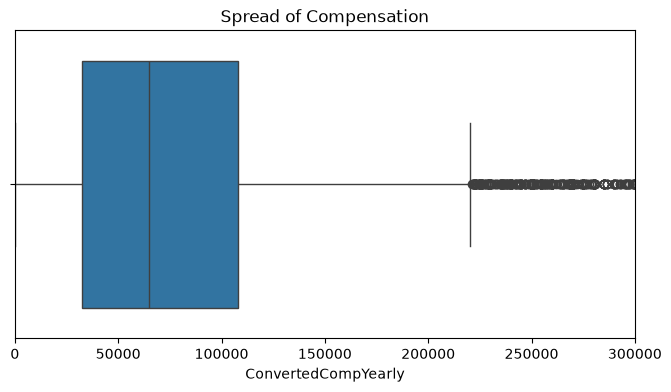

count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64

In [17]:
## Write your code here
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# Convert to numeric
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')

# 1. Histogram
df_filtered = df[df['ConvertedCompYearly'] < 2000000]
df_filtered.plot.hist(y='ConvertedCompYearly',bins=50, figsize=(10,5))
plt.title('Histogram of ConvertedCompYearly')
plt.xlabel('Yearly Compensation')
plt.ylabel('Count')
plt.xlim(0, 0.75e6)
plt.show()

# 2. Distribution (with KDE)
df_filtered = df[df['ConvertedCompYearly'] < 2000000]
ax = df_filtered['ConvertedCompYearly'].plot.kde(figsize=(10,5))
ax.fill_between(ax.lines[0].get_xdata(), ax.lines[0].get_ydata(), alpha=0.3)
plt.title('Distribution of ConvertedCompYearly')
plt.xlabel('Yearly Compensation')
plt.xlim(0, 0.75e6) # zoom to see spread better, remove extreme outliers
plt.show()



# 3. Boxplot to see spread
plt.figure(figsize=(8,4))
sns.boxplot(x=df['ConvertedCompYearly'])
plt.xlim(0, 300000)
plt.title('Spread of Compensation')
plt.show()

print(df['ConvertedCompYearly'].describe())

<h3>Step 4: Calculate Median Compensation for Full-Time Employees</h3>


**Task**: Filter the data to calculate the median compensation for respondents whose employment status is "Employed, full-time."


In [16]:
df[df['Employment'] == 'Employed, full-time']['ConvertedCompYearly'].median()

np.float64(69814.0)

<h3>Step 5: Analyzing Compensation Range and Distribution by Country</h3>


Explore the range of compensation in the ConvertedCompYearly column by analyzing differences across countries. Use box plots to compare the compensation distributions for each country to identify variations and anomalies within each region, providing insights into global compensation trends.



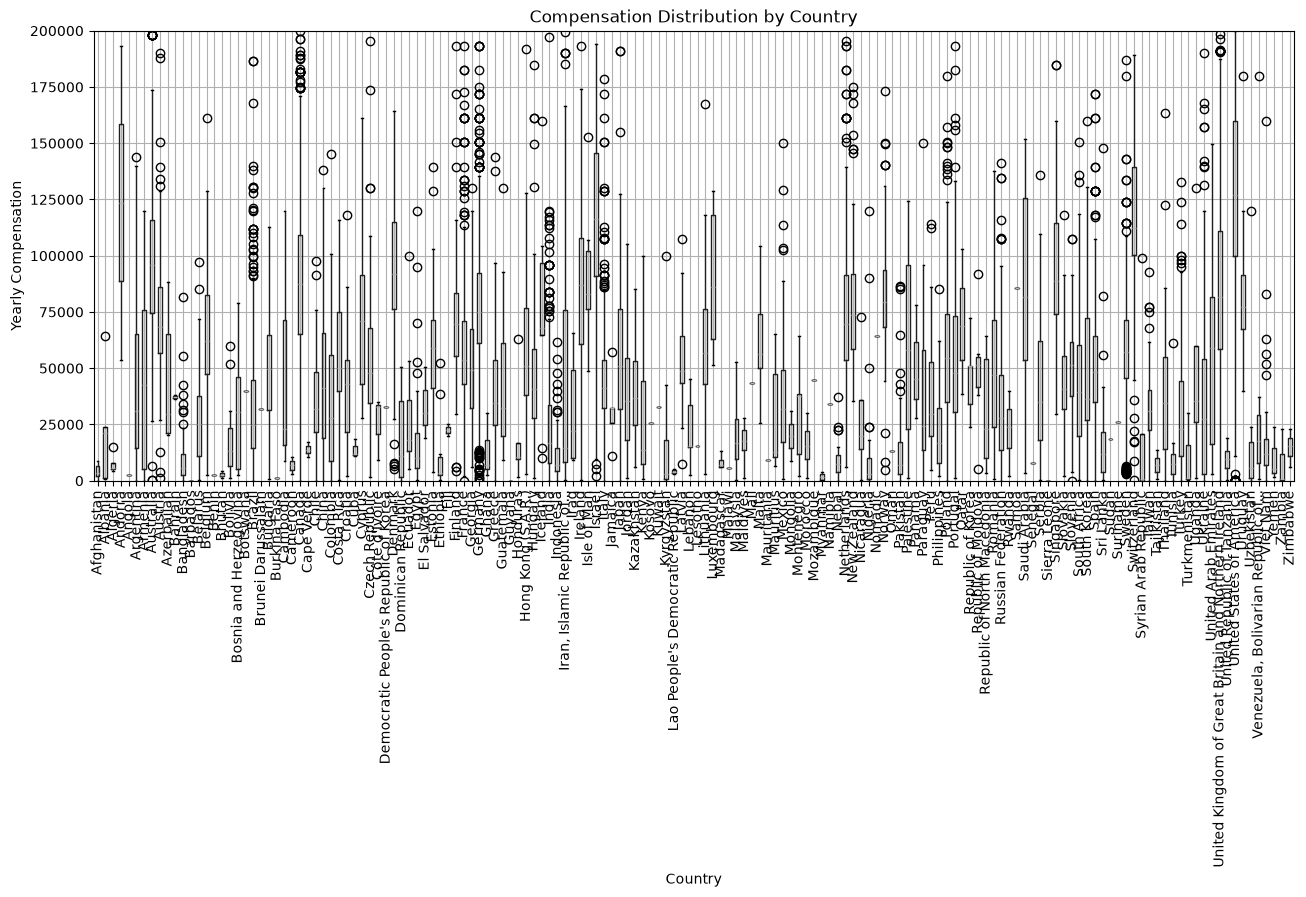

In [18]:
## Write your code here
import matplotlib.pyplot as plt

# keep only full-time and reasonable comp to make boxplot readable
df_filtered = df[(df['Employment'] == 'Employed, full-time') & (df['ConvertedCompYearly'] < 200000)]

df_filtered.boxplot(column='ConvertedCompYearly', by='Country', figsize=(15,6), rot=90)

plt.title('Compensation Distribution by Country')
plt.suptitle('') # removes pandas auto title
plt.xlabel('Country')
plt.ylabel('Yearly Compensation')
plt.ylim(0, 200000)
plt.show()

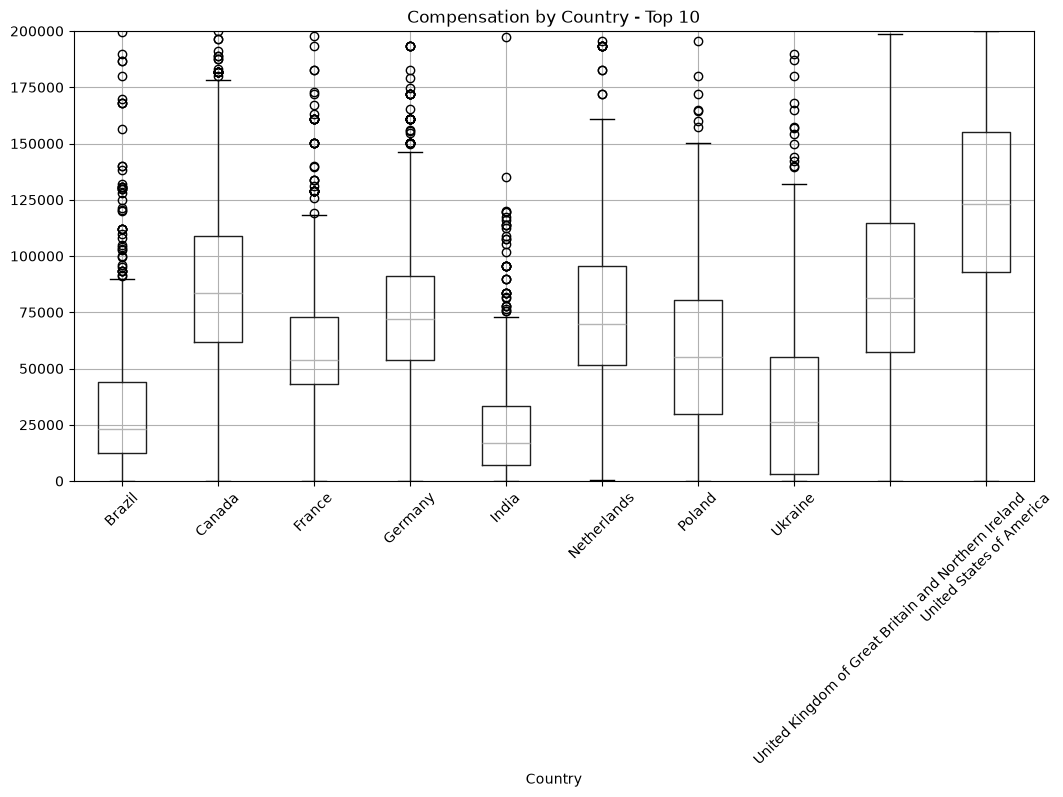

In [19]:
top_countries = df['Country'].value_counts().head(10).index
df_top = df[df['Country'].isin(top_countries) & (df['ConvertedCompYearly'] < 200000)]

df_top.boxplot(column='ConvertedCompYearly', by='Country', figsize=(12,6), rot=45)
plt.title('Compensation by Country - Top 10')
plt.suptitle('')
plt.ylim(0, 200000)
plt.show()

<h3>Step 6: Removing Outliers from the Dataset</h3>


**Task**: Create a new DataFrame by removing outliers from the `ConvertedCompYearly` column to get a refined dataset for correlation analysis.


In [20]:
## Write your code here
# Calculate IQR
Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# New DataFrame without outliers
df_no_outliers = df[(df['ConvertedCompYearly'] >= lower_bound) & 
                    (df['ConvertedCompYearly'] <= upper_bound)]

print(f"Original: {df.shape}, Refined: {df_no_outliers.shape}")
print(f"Bounds: {lower_bound} - {upper_bound}")
df_no_outliers.head(3)

Original: (65437, 114), Refined: (22457, 114)
Bounds: -80177.25 - 220860.75

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
72,73,I am a developer by profession,18-24 years old,"Employed, full-time;Student, full-time;Indepen...","Hybrid (some remote, some in-person)",Apples,Hobby;School or academic work;Professional dev...,"Secondary school (e.g. American high school, G...",On the job training;Other online resources (e....,Technical documentation;Blogs;Written Tutorial...,...,65.0,100.0,100.0,100.0,50.0,90.0,Too long,Easy,7322.0,10.0
374,375,"I am not primarily a developer, but I write co...",25-34 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby;School or academic work;Professional dev...,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",Books / Physical media;Colleague;On the job tr...,Written Tutorials;Stack Overflow;Written-based...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Neither easy nor difficult,30074.0,NaN
379,380,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Bootstrapping a business,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Other online resources ...,Technical documentation;Books;Social Media;Wri...,...,0.0,0.0,0.0,0.0,0.0,0.0,Too long,Difficult,91295.0,10.0


<h3>Step 7: Finding Correlations Between Key Variables</h3>


**Task**: Calculate correlations between `ConvertedCompYearly`, `WorkExp`, and `JobSatPoints_1`. Visualize these correlations with a heatmap.


                     ConvertedCompYearly   WorkExp  JobSatPoints_1
ConvertedCompYearly             1.000000  0.408438       -0.058170
WorkExp                         0.408438  1.000000       -0.032388
JobSatPoints_1                 -0.058170 -0.032388        1.000000

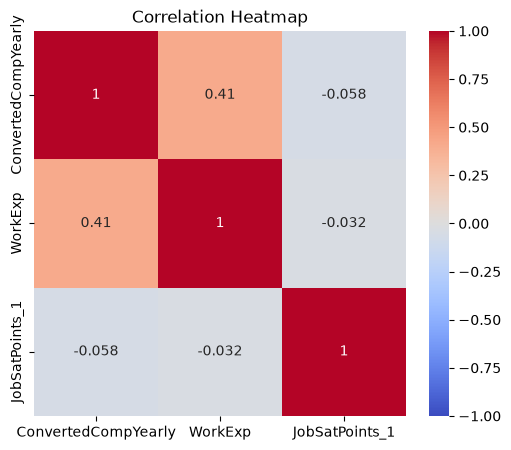

In [21]:
## Write your code here
import seaborn as sns
import matplotlib.pyplot as plt

# use refined df from previous step
cols = ['ConvertedCompYearly', 'WorkExp', 'JobSatPoints_1']
df_corr = df_no_outliers[cols]

# correlation matrix
corr_matrix = df_corr.corr()
print(corr_matrix)

# heatmap
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

<h3>Step 8: Scatter Plot for Correlations</h3>


**Task**: Create scatter plots to examine specific correlations between `ConvertedCompYearly` and `WorkExp`, as well as between `ConvertedCompYearly` and `JobSatPoints_1`.


Correlation between Comp and WorkExp: 0.4084376442532557

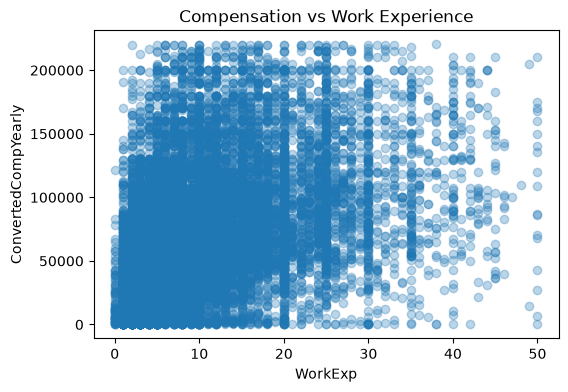

Correlation between Comp and WorkExp: -0.058170458996714226

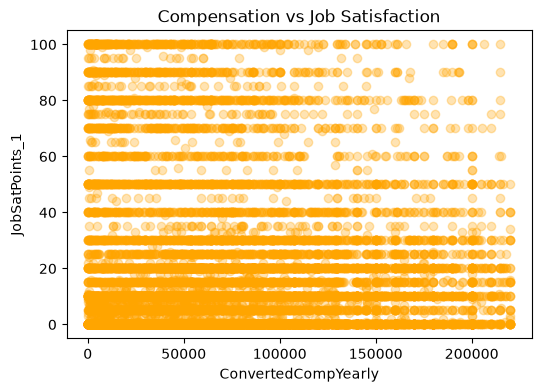

In [22]:
## Write your code here
import matplotlib.pyplot as plt
%matplotlib inline
corr = df_no_outliers['ConvertedCompYearly'].corr(df_no_outliers['WorkExp'])
print(f"Correlation between Comp and WorkExp: {corr}")
plt.figure(figsize=(6,4))
plt.scatter( df_no_outliers['WorkExp'],df_no_outliers['ConvertedCompYearly'], alpha=0.3)
plt.xlabel('WorkExp')
plt.ylabel('ConvertedCompYearly')
plt.title('Compensation vs Work Experience')
plt.show()
#calculate the corr coef
# calculate correlation for the same 2 columns you plotted

# for both if needed
corr = df_no_outliers['ConvertedCompYearly'].corr(df_no_outliers['JobSatPoints_1'])
print(f"Correlation between Comp and WorkExp: {corr}")
plt.figure(figsize=(6,4))
plt.scatter( df_no_outliers['ConvertedCompYearly'],df_no_outliers['JobSatPoints_1'], alpha=0.3, color='orange')
plt.xlabel('ConvertedCompYearly')
plt.ylabel('JobSatPoints_1')
plt.title('Compensation vs Job Satisfaction')
plt.show()

<h3>Summary</h3>


In this lab, you practiced essential skills in correlation analysis by:

- Examining the distribution of yearly compensation with histograms and box plots.
- Detecting and removing outliers from compensation data.
- Calculating correlations between key variables such as compensation, work experience, and job satisfaction.
- Visualizing relationships with scatter plots and heatmaps to gain insights into the associations between these features.

By following these steps, you have developed a solid foundation for analyzing relationships within the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
